In [120]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This will copy the file path in the file_path variable


In [121]:
file_path='/content/drive/MyDrive/dataset/train.csv'

Importing pandas liabaries for reading of data

In [122]:

import pandas as pd

In [123]:
nfive=pd.read_csv(file_path)

Now printing top 5 rows

In [124]:
nfive.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [125]:
print("Dataset Info")
nfive.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [126]:
print("Statistical Summary")
nfive.describe()

Statistical Summary


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [127]:
print("Rows & Coulmns")
nfive.shape

Rows & Coulmns


(891, 12)

In [128]:
print("Missing Values Column")
nfive.isnull().sum()[nfive.isnull().sum() > 0]

Missing Values Column


,0
Age,177
Cabin,687
Embarked,2


In [129]:
numerical_columns=nfive.select_dtypes(include=['number']).columns
print(numerical_columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


In [130]:
categorical_coulmns=nfive.select_dtypes(include=['object','category']).columns
print(categorical_coulmns)

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


In [131]:
print("Numerical_Columns:",numerical_columns.tolist())
print("Categorical_Columns:",categorical_coulmns.tolist())
print("Numerical_coulnms:",len(numerical_columns))
print("Categorical_coulnms:",len(categorical_coulmns))

Numerical_Columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical_Columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical_coulnms: 7
Categorical_coulnms: 5


This notebook begins by mounting Google Drive and loading the Titanic_test.csv dataset into a pandas DataFrame named nfive. Initial data exploration is performed, including displaying the first few rows, checking data types and non-null counts with info(), and generating descriptive statistics with describe(). It also identifies missing values in 'Age', 'Fare', and 'Cabin' columns, and explicitly lists both numerical and categorical features present in the dataset.

Now Immplementing Task 1 part 2 Missing Values


In [132]:
#importing Liabraries
import matplotlib.pyplot as plt
import seaborn as sns

In [133]:
print("Missing Values Column")
nfive.isnull().sum()[nfive.isnull().sum() > 0]

Missing Values Column


,0
Age,177
Cabin,687
Embarked,2


In [134]:
nfive['Age']=nfive['Age'].fillna(nfive['Age'].mean())


In [135]:
nfive['Embarked'] = nfive['Embarked'].fillna(nfive['Embarked'].mode()[0])

In [136]:
nfive=nfive.drop(columns=['Cabin'])

In [137]:
print("Missing Values")
nfive.isnull().sum()[nfive.isnull().sum()>0]

Missing Values


,0


In [138]:
print("Missing Values")
nfive.isnull().sum()[nfive.isnull().sum()>0]

Missing Values


,0


### Handling Missing Values Justification

- **Age:** The Age column contained **177 missing values**, which were filled using the **median**. Since Age is a numerical feature and may contain outliers, the median is more robust than the mean and helps preserve the dataset without removing records.

- **Embarked:** The Embarked column contained only **2 missing values**, which were filled using the **mode** because it is a categorical feature. The mode represents the most frequently occurring category and is the most appropriate imputation method.

- **Cabin:** The Cabin column contained **687 missing values**, representing a large portion of the dataset. Imputing such a high number of missing values could introduce bias and reduce data quality. Therefore, the Cabin column was removed from the dataset.

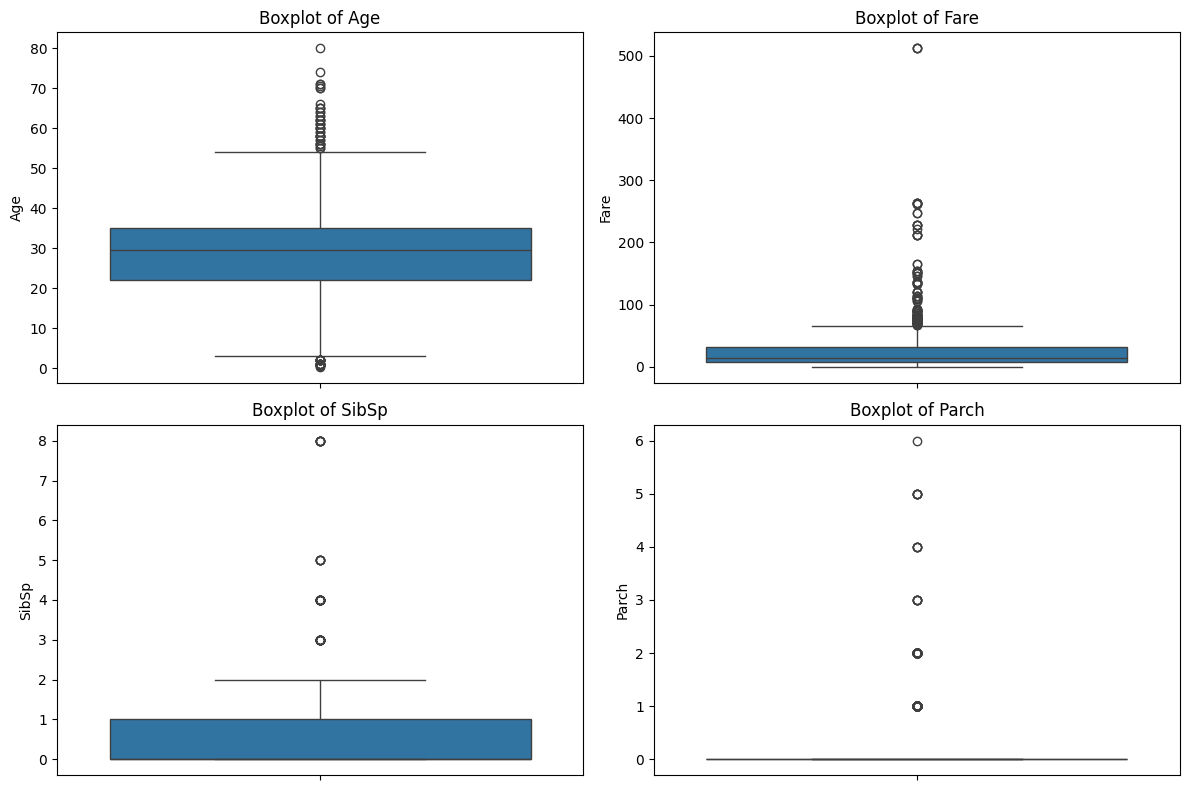

In [139]:

numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

plt.figure(figsize=(12,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=nfive[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

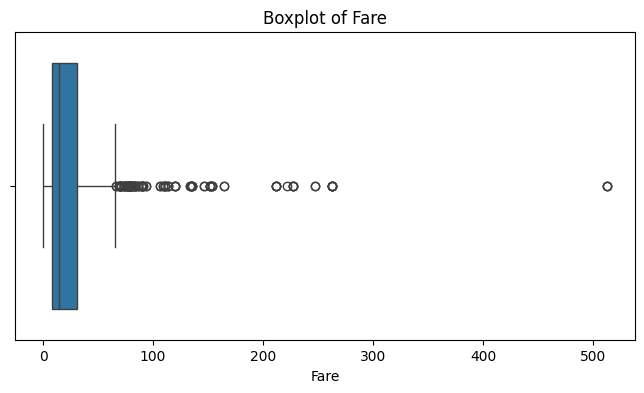

In [140]:
plt.figure(figsize=(8,4))
sns.boxplot(x=nfive['Fare'])
plt.title("Boxplot of Fare")
plt.show()

The boxplot shows several outliers in the Fare column. These represent passengers who paid significantly higher ticket prices than most others. Such outliers are expected because Titanic passengers belonged to different ticket classes.

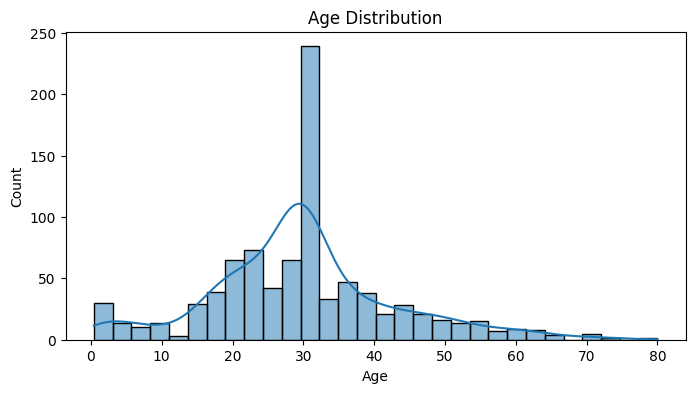

In [141]:
#Histogram
plt.figure(figsize=(8,4))
sns.histplot(nfive['Age'],bins=30,kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel('Count')
plt.show()

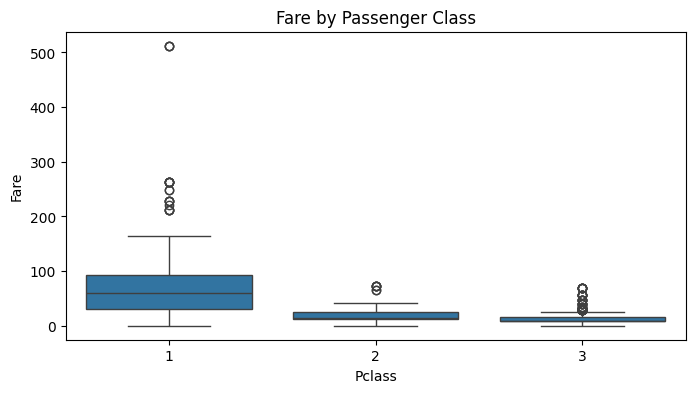

In [142]:
#BoxPlot
plt.figure(figsize=(8,4))
sns.boxplot(x=nfive['Pclass'],y=nfive['Fare'])
plt.title("Fare by Passenger Class")
plt.show()

In [143]:
nfive['Sex'] = nfive['Sex'].map({'male': 0, 'female': 1})

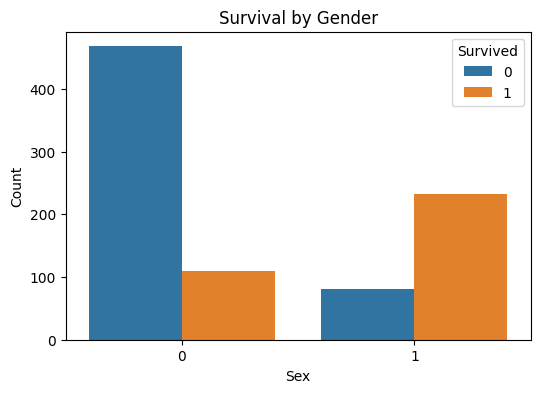

In [144]:
#BarChart

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=nfive)
plt.title("Survival by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

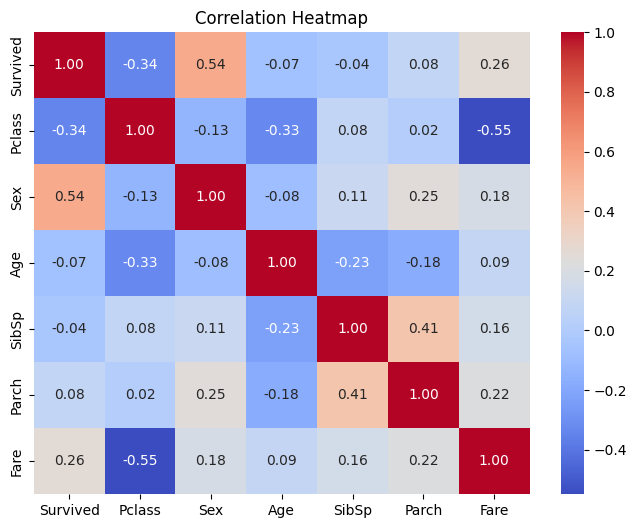

In [145]:
#corelation Heatmap
plt.figure(figsize=(8,6))
corr = nfive[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

According to the correlation heatmap, the Sex feature has the strongest relationship with survival (correlation = 0.54). This indicates that gender had the greatest influence on survival, with female passengers being more likely to survive than male passengers. Passenger class (Pclass) also showed a moderate negative correlation (-0.34), suggesting that passengers in higher classes had better survival chances